## Exercise: Simple Lasso and Ridge Regularization
Source: This notebook comes from [Harvard lecture on Ridge and Lasso](https://harvard-iacs.github.io/2021-CS109A/lectures/lecture06/notebook-1/), with some changes.

## Description :
The aim of this exercise is to understand **Lasso and Ridge regularization.**


## Data Description:

## Instructions:

- Read the dataset and assign the predictor and response variables.
- Split the dataset into train and validation sets.
- Fit a multi-linear regression model.
- Compute the validation MSE of the model.
- Compute the coefficient of the predictors and store to the plot later.
- Implement Lasso regularization by specifying an alpha value. Repeat steps 4 and 5.
- Implement Ridge regularization by specifying the same alpha value. Repeat steps 4 and 5.
- Plot the coefficient of all the 3 models in one graph as shown above.

## Hints: 

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html" target="_blank">sklearn.normalize()</a>
Scales input vectors individually to the unit norm (vector length)

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html" target="_blank">sklearn.train_test_split()</a>
Splits the data into random train and test subsets

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html" target="_blank">sklearn.LinearRegression()</a>
LinearRegression fits a linear model

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.fit" target="_blank">sklearn.fit()</a>
Fits the linear model to the training data

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html#sklearn.linear_model.LinearRegression.predict" target="_blank">sklearn.predict()</a>
Predict using the linear modReturns the coefficient of the predictors in the model.

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mean_squared_error.html" target="_blank">mean_squared_error()</a>
Mean squared error regression loss

<a href="http://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html" target="_blank">sklearn.Lasso()</a>
Linear Model trained with L1 prior as a regularizer

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html" target="_blank">sklearn.Ridge()</a>
Linear least squares with L2 regularization

**Note:** This exercise is auto-graded and you can try multiple attempts. 

In [37]:
# Import necessary libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.datasets import load_diabetes
from sklearn.linear_model import Ridge, RidgeCV
from sklearn.linear_model import Lasso, LassoCV
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


### Reading the dataset
We are using the diabetes dataset from `sklearn`, a very good learning dataset. Please note that this dataset has been cleaned and preprocessed purposedly for learning. This notebook focuses on Linear vs Ridge vs Lasso, but remember that **standardization is necessary for Ridge and Lasso regularization** (more on that in the other notebooks).

*Data Set Characteristics* (taken from [Sklearn](https://scikit-learn.org/stable/datasets/toy_dataset.html#diabetes-dataset) ):

- Number of Instances: 442
- Number of Attributes: First 10 columns are numeric predictive values
- Target: Column 11 is a quantitative measure of disease progression one year after baseline
- Attribute Information:

    -    age (in years)

    -    sex

    -    bmi (body mass index)

    -    bp (average blood pressure)

    -    s1: tc, total serum cholesterol

    -    s2: ldl, low-density lipoproteins

    -    s3: hdl, high-density lipoproteins

    -    s4: tch, total cholesterol / HDL

    -    s5: ltg, possibly log of serum triglycerides level

    -    s6: glu, blood sugar level

Note: Each of these 10 feature variables have been mean centered and scaled by the standard deviation times the square root of n_samples (i.e. the sum of squares of each column totals 1).

In [38]:
diabetes = load_diabetes(as_frame=True)

df = diabetes.frame

df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [39]:
# Select columns

X = df.drop(columns=['target'])
y = df['target']

### Split the dataset into train and validation sets


In [40]:
### edTest(test_random) ###
# Split the data into train and validation sets with 80% train data and
# random_state as 42
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

For methods with **regularization**, it is very important to standardize the data, because regularization penalties are sensitive to the input feature scale: different scales would cause the penalization of features to be different. Standardization follows this formula: 
$$
z = \frac{x - \mu}{\sigma}
$$
What we are doing is essentially transforming the mean of the original data to $\mu$=o and squishing or expanding the points to unit standard deviation ($\sigma$=1), without affecting the shape of the distribution.

In [41]:
# Standardize features
scaler = StandardScaler()
scaler.fit(X_train)
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# If you need to standardize manually, here is how you can do it:
#df["area_standardized"] = (df["area"] - df["area"].mean())/(df["area"].std())

### Linear Regression Analysis

In [42]:
# Initialize a Linear Regression model
lreg = LinearRegression()

# Fit the linear model on the train data
lreg.fit(X_train, y_train)

# Predict on the validation data
y_test_pred = lreg.predict(X_test)


In [43]:
# Use the mean_squared_error function to compute the validation mse
mse = mean_squared_error(y_test, y_test_pred)

# Print the MSE value
print ("Linear regression validation RMSE is", np.sqrt(mse))


Linear regression validation RMSE is 53.85344583676593


### Obtaining the coefficients of the predictors

In [44]:
# Helper code to create a dictionary of the coefficients 
# along with the predictors as keys
lreg_coef = dict(zip(X.columns, np.transpose(lreg.coef_)))

# Linear regression coefficients for plotting
lreg_x = list(lreg_coef.keys())
lreg_y = list(lreg_coef.values())


### Implementing Lasso regularization

Differently from the other notebook, we will use Cross-Validation to select the best alpha values. What we are doing is trying out several values in a range, and automatically printing out the best one. To do this, look carefully at the parameters of `LassoCV`:

- alphas: here you select all the alpha values you want to try
- cv: This is the `k` in your `k-fold` cross-validation: if it is set to 5, you split the data into 5 parts (4 train, 1 test), and train on each one (so you train 5 times, trying out each test set).
- max_iter: Lasso regression is an iterative process, so you need to set a max. Differently from it, Ridge is not iterative, so you won't need this parameter.

In [45]:
alphas = np.logspace(-6, 10, 50) # create 50 numbers evenly spaced on a logarithmic scale between 10^-6 and 10^10

# Create a Lasso Regression model with alpha as 0.008
lasso_reg = LassoCV(alphas=alphas, cv=5, max_iter=10000)

# Fit the model on the train data
lasso_reg.fit(X_train, y_train)

print("Best alpha:", lasso_reg.alpha_)

# Predict on the validation data using the trained model
y_test_pred =lasso_reg.predict(X_test)


Best alpha: 0.07906043210907686


### Computing the MSE with Lasso regularization

In [46]:
# Calculate the validation MSE
mse_lasso = mean_squared_error(y_test, y_test_pred)

# Print the validation MSE
print ("Lasso validation RMSE is", np.sqrt(mse_lasso))


Lasso validation RMSE is 52.91618912053665


In [47]:
# Hhelper code to make a dictionary of the predictors 
# along with the coefficients associated with them
lasso_coef = dict(zip(X.columns, np.transpose(lasso_reg.coef_))) 

# Get the Lasso regularisation coefficients for plotting
lasso_x = list(lasso_coef.keys())
lasso_y = list(lasso_coef.values())


### Implementing Ridge regularization

In [48]:
alphas = np.logspace(-6, 4, 50)

# Create a Ridge Regression model with alpha as 0.4
ridgeReg = RidgeCV(alphas=alphas, cv=5)

# Fit the model on the train data
ridgeReg.fit(X_train, y_train)

print("Best alpha:", ridgeReg.alpha_)

# Predict the trained model on the validation data
y_test_pred = ridgeReg.predict(X_test)


Best alpha: 0.07906043210907701


### Computing the MSE with Ridge regularization

In [49]:
### edTest(test_mse) ###

# Calculate the validation MSE
mse_ridge = mean_squared_error(y_test, y_test_pred)

# Print he valdiation MSE
print ("Ridge validation RMSE is", np.sqrt(mse_ridge))


Ridge validation RMSE is 53.47579606931665


### Obtaining the coefficients of the predictors

In [50]:
# Helper code to make a dictionary of the predictors 
# along with the coefficients associated with them 
ridge_coef = dict(zip(X.columns, np.transpose(ridgeReg.coef_))) 

# Ridge regularisation coefficients for plotting
ridge_x = list(ridge_coef.keys())
ridge_y = list(ridge_coef.values())


### Plotting the graph

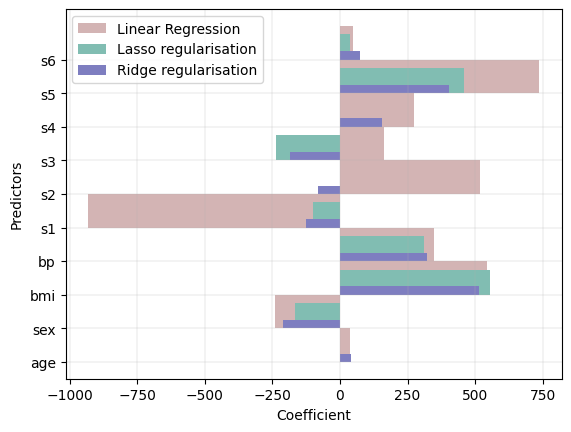

In [51]:
# Helper code below to visualise your results

plt.rcdefaults()

plt.barh(lreg_x,lreg_y,1.0, align='edge',color="#D3B4B4", label="Linear Regression")
plt.barh(lasso_x,lasso_y,0.75 ,align='edge',color="#81BDB2",label = "Lasso regularisation")
plt.barh(ridge_x,ridge_y,0.25 ,align='edge',color="#7E7EC0", label="Ridge regularisation")
plt.grid(linewidth=0.2)
plt.xlabel("Coefficient")
plt.ylabel("Predictors")
plt.legend(loc='best')
#plt.xlim(-6500,3500)
plt.show()


#### ⏸ How does the performance of Lasso and Ridge regression compare with that of Linear regression?

In [52]:
### edTest(test_chow1) ###
# Submit an answer choice as a string below 
answer1 = '___'


#### ⏸ Change the alpha values for both, Lasso and Ridge, to 1000. What happens to the coefficients?


In [53]:
### edTest(test_chow2) ###
# Submit an answer choice as a string below 
answer2 = '___'
